In [1]:
import pandas as pd

# File paths
public_path = "data/stack-overflow-developer-survey-2025/survey_results_public.csv"
schema_path = "data/stack-overflow-developer-survey-2025/survey_results_schema.csv"

# Load CSVs
public_df = pd.read_csv(public_path)
schema_df = pd.read_csv(schema_path)

print("=== Public Survey Dataset Schema ===")
print(public_df.info())

print("\n=== First few columns ===")
print(public_df.columns.tolist())

print("\n=== Schema Dataset (Question Mapping) ===")
print(schema_df.head(20))

C:\Users\Anish\AppData\Local\Temp\ipykernel_100\1190712825.py:8: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  public_df = pd.read_csv(public_path)


=== Public Survey Dataset Schema ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB
None

=== First few columns ===
['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2', 'TechEndorse_3', 'TechEndorse_4', 'TechEndorse_5', 'TechEndorse_6', 'TechEndorse_7', 'TechEndorse_8', 'TechEndorse_9', 'TechEndorse_13', 'TechEndorse_13_TEXT', 'TechOppose_1', 'TechOppose_2', 'TechOppose_3', 'TechOppose_5', 'TechOppose_7', 'TechOppose_9', 'TechOppose_11', 'TechOppose_13', 'TechOppose_16', 'TechOppose_15', 'TechOppose_15_TEXT', 'Industry', 'JobSatPoints_1', 'JobSatPoints_2', 'JobSatPoints_3', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints

In [2]:
ai_cols = [
    "AISent",
    "AIAcc",
    "AIThreat",
    "AIFrustration",
    "AIExplain"
]

ai_df = public_df[ai_cols]

ai_df.head()

,AISent,AIAcc,AIThreat,AIFrustration,AIExplain
0,Indifferent,Neither trust nor distrust,I'm not sure,"AI solutions that are almost right, but not quite",No
1,Indifferent,Neither trust nor distrust,I'm not sure,"AI solutions that are almost right, but not qu...",No
2,Favorable,Somewhat trust,No,"AI solutions that are almost right, but not qu...",No
3,Favorable,Somewhat trust,No,"AI solutions that are almost right, but not qu...",NO
4,Favorable,Neither trust nor distrust,No,"AI solutions that are almost right, but not quite",partly


In [3]:
for col in ai_cols:
    print(f"\n===== {col} =====")
    print(public_df[col].value_counts())


===== AISent =====
AISent
Favorable           12311
Very favorable       7677
Indifferent          5880
Unfavorable          3621
Very unfavorable     3219
Unsure                759
Name: count, dtype: int64

===== AIAcc =====
AIAcc
Somewhat trust                9869
Somewhat distrust             8685
Neither trust nor distrust    7162
Highly distrust               6533
Highly trust                  1048
Name: count, dtype: int64

===== AIThreat =====
AIThreat
No              22958
I'm not sure     7700
Yes              5420
Name: count, dtype: int64

===== AIFrustration =====
AIFrustration
AI solutions that are almost right, but not quite                                                                                                                                                                             6188
AI solutions that are almost right, but not quite;Debugging AI-generated code is more time-consuming                                                                          

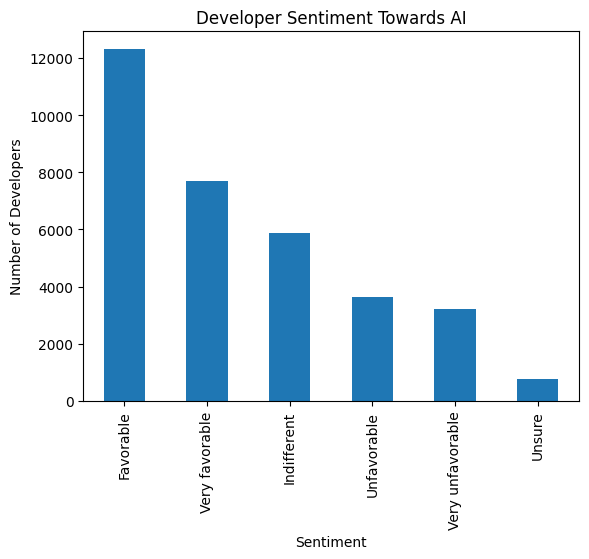

In [4]:
import matplotlib.pyplot as plt

public_df["AISent"].value_counts().plot(kind="bar")

plt.title("Developer Sentiment Towards AI")
plt.ylabel("Number of Developers")
plt.xlabel("Sentiment")
plt.show()

In [5]:
from collections import Counter

text_data = public_df["TechEndorse_13_TEXT"].dropna()

words = " ".join(text_data).lower().split()

common_words = Counter(words).most_common(20)

print(common_words)

[('documentation', 289), ('and', 216), ('ai', 207), ('good', 202), ('to', 179), ('of', 173), ('the', 156), ('not', 120), ('it', 96), ('for', 93), ('support', 89), ('a', 81), ('in', 78), ('no', 78), ('i', 76), ('is', 72), ('security', 72), ('community', 70), ('anything', 68), ('open', 62)]


In [6]:
public_df["Country"].value_counts().head(10)

Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Canada                                                  1305
Ukraine                                                  964
Poland                                                   888
Netherlands                                              867
Italy                                                    835
Name: count, dtype: int64

In [7]:
ai_country = public_df.groupby("Country")["AISent"].value_counts().unstack()

ai_country.head()

AISent,Favorable,Indifferent,Unfavorable,Unsure,Very favorable,Very unfavorable
Country,,,,,,
Afghanistan,1.0,3.0,NaN,NaN,5.0,1.0
Albania,5.0,5.0,2.0,NaN,9.0,NaN
Algeria,24.0,1.0,1.0,NaN,13.0,2.0
Andorra,NaN,2.0,NaN,NaN,3.0,NaN
Angola,2.0,1.0,NaN,NaN,4.0,NaN


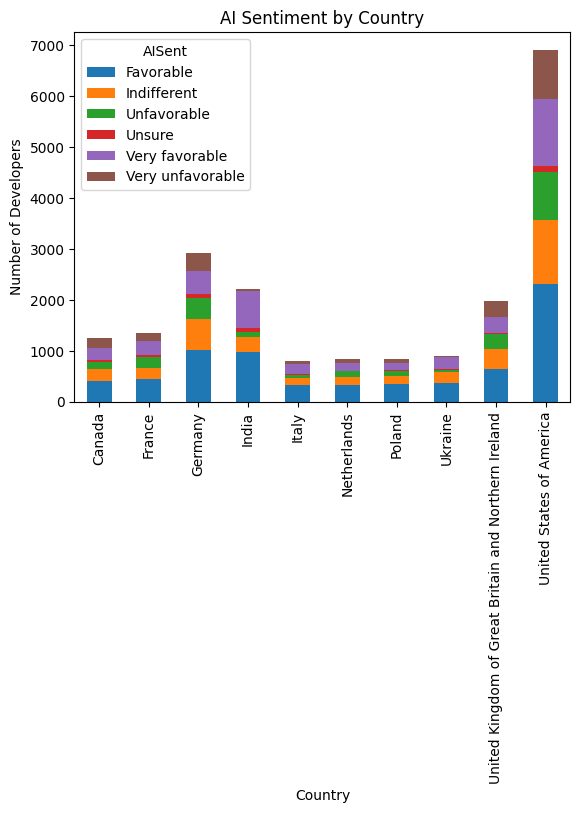

In [8]:
top_countries = public_df["Country"].value_counts().head(10).index

country_ai = public_df[public_df["Country"].isin(top_countries)]

country_ai.groupby("Country")["AISent"].value_counts().unstack().plot(kind="bar", stacked=True)

plt.title("AI Sentiment by Country")
plt.ylabel("Number of Developers")
plt.show()

In [9]:
salary_ai = public_df.groupby("AISent")["ConvertedCompYearly"].mean()

salary_ai

AISent
Favorable            96258.109226
Indifferent          97887.577619
Unfavorable         105569.824490
Unsure              117073.833766
Very favorable      108656.855774
Very unfavorable    105706.468127
Name: ConvertedCompYearly, dtype: float64

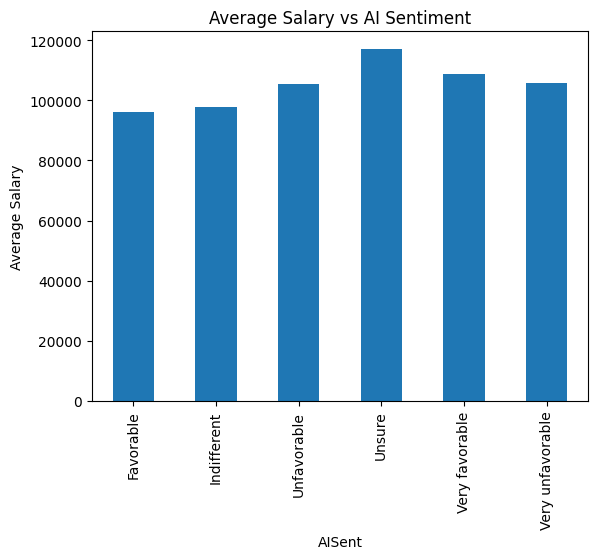

In [10]:
salary_ai.plot(kind="bar")

plt.title("Average Salary vs AI Sentiment")
plt.ylabel("Average Salary")
plt.show()

In [11]:
public_df["SOVisitFreq"].value_counts()

SOVisitFreq
A few times per month or weekly          9649
A few times per week                     9156
Daily or almost daily                    5454
Less than once per month or monthly      3511
Multiple times per day                   2662
Less than once every 2 - 3 months        1342
Infrequently, less than once per year     936
Name: count, dtype: int64

In [12]:
public_df["SOPartFreq"].value_counts()

SOPartFreq
Infrequently, less than once per year                 12067
I have never participated in Q&A on Stack Overflow     9964
Less than once every 2 - 3 months                      4589
Less than once per month or monthly                    2426
A few times per month or weekly                        1906
A few times per week                                    759
Daily or almost daily                                   335
Multiple times per day                                  182
Name: count, dtype: int64

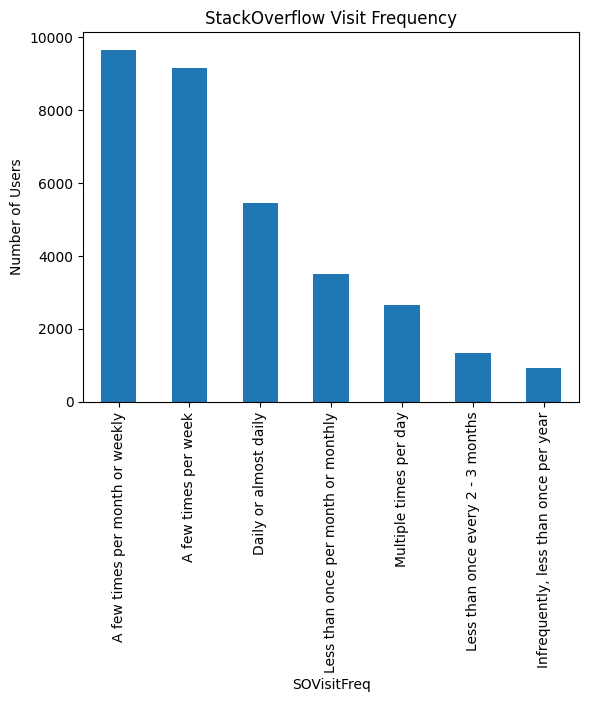

In [13]:
public_df["SOVisitFreq"].value_counts().plot(kind="bar")

plt.title("StackOverflow Visit Frequency")
plt.ylabel("Number of Users")
plt.show()

In [14]:
!pip install wordcloud

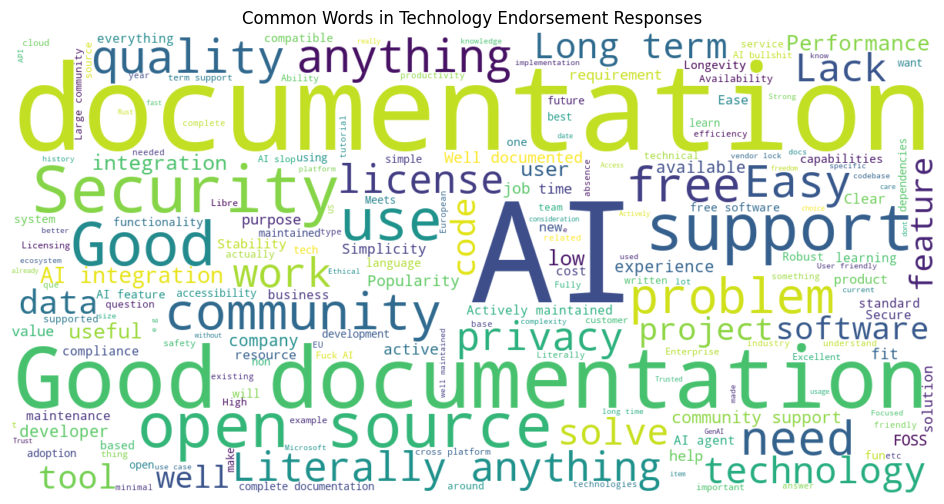

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_data = public_df["TechEndorse_13_TEXT"].dropna()

text = " ".join(text_data.astype(str))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Technology Endorsement Responses")
plt.show()

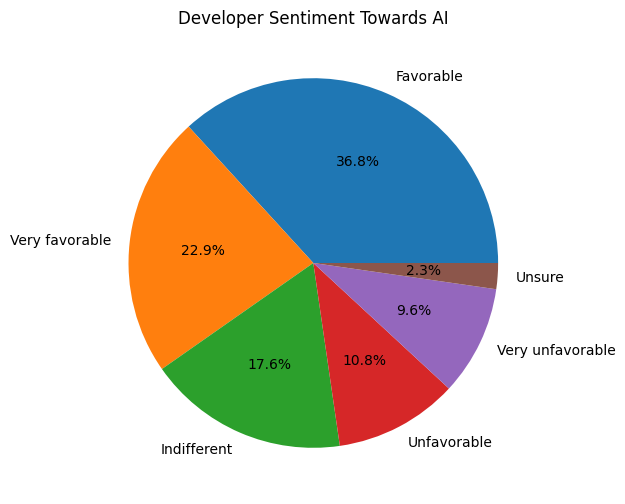

In [16]:
public_df["AISent"].value_counts().plot(
    kind="pie",
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Developer Sentiment Towards AI")
plt.ylabel("")
plt.show()